# Logistic Regression

## 1. What is Logistic Regression?

Logistic Regression is a **supervised machine learning algorithm used for classification problems**.

Despite its name, Logistic Regression is a **classification algorithm**, not a regression algorithm.

It predicts the **probability that an input belongs to a particular class**.

### Example

Suppose we want to predict whether a student will pass:

* `0 → Fail`
* `1 → Pass`

The model first predicts a probability:

```text
P(Pass) = 0.82
```

Then we convert the probability into a class using a threshold:

```text
Probability >= 0.5 → Class 1
Probability < 0.5  → Class 0
```

---

# 2. Why Not Linear Regression?

Suppose we use Linear Regression for classification.

Linear Regression produces:

```text
-2.5
 0.4
 1.7
 5.2
```

These values are not valid probabilities.

A probability must always lie between:

```text
0 and 1
```

Therefore, we need a function that converts any real-valued number into the range `[0, 1]`.

This is where the **Sigmoid Function** comes in.

---

# 3. Basic Idea

Logistic Regression works in two major steps:

```text
Input Features
      ↓
Linear Equation
      ↓
z = w₁x₁ + w₂x₂ + ... + b
      ↓
Sigmoid Function
      ↓
Probability
      ↓
Threshold
      ↓
Class Prediction
```

---

# 4. Linear Equation

The first step is exactly like Linear Regression.

For one feature:

$$
z = wx + b
$$

For multiple features:

$$
z = w_1x_1 + w_2x_2 + ... + w_nx_n + b
$$

In vector notation:

$$
z = Xw + b
$$

Here:

* `X` → input features
* `w` → model weights
* `b` → bias/intercept
* `z` → linear score

The value `z` can be anything from:

```text
-∞ to +∞
```

So it is not yet a probability.

---

# 5. Sigmoid Function

The sigmoid function converts `z` into a value between `0` and `1`.

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

Therefore:

$$
P(y=1|X) = \frac{1}{1+e^{-z}}
$$

where:

$$
z = Xw+b
$$

So the complete equation is:

$$
P(y=1|X)
=
\frac{1}{1+e^{-(Xw+b)}}
$$

### Important Properties

|  z | Sigmoid(z) |
| -: | ---------: |
| -∞ |        → 0 |
| -2 |    ≈ 0.119 |
|  0 |        0.5 |
|  2 |    ≈ 0.881 |
| +∞ |        → 1 |

The sigmoid function is therefore useful for binary classification.

---

# 6. Understanding the Probability

Suppose:

```text
P(y=1) = 0.85
```

This means the model estimates an **85% probability for class 1**.

It does NOT directly mean:

```text
85% of the data belongs to class 1
```

It refers to the model's estimated probability for that particular sample.

---

# 7. Decision Threshold

After calculating the probability, we need to convert it into a class.

The common threshold is:

$$
threshold = 0.5
$$

Therefore:

```text
if probability >= 0.5:
        prediction = 1
else:
        prediction = 0
```

Example:

```text
0.82 → Class 1
0.63 → Class 1
0.49 → Class 0
0.12 → Class 0
```

The threshold does not have to be 0.5. It can be changed depending on the application.

---

# 8. Why is 0.5 Important?

The sigmoid function gives:

$$
\sigma(0)=0.5
$$

Therefore:

```text
z > 0 → probability > 0.5 → class 1

z < 0 → probability < 0.5 → class 0
```

So the decision boundary occurs at:

$$
z=0
$$

Since:

$$
z = w_1x_1+w_2x_2+b
$$

the decision boundary is:

$$
w_1x_1+w_2x_2+b=0
$$

This is why Logistic Regression is called a **linear classifier**.

---

# 9. Decision Boundary

The decision boundary separates the classes.

For two features:

$$
w_1x_1+w_2x_2+b=0
$$

This produces a straight line.

For three features, it becomes a plane.

For higher dimensions, it becomes a **hyperplane**.

```text
Class 0       |       Class 1
              |
              |
--------------|--------------  ← Decision Boundary
              |
              |
```

---

# 10. Logistic Regression and the Perceptron

Both Logistic Regression and the Perceptron use a linear decision boundary:

$$
w^Tx+b
$$

But they are different.

### Perceptron

The Perceptron directly makes a class prediction using a step function.

```text
z >= 0 → 1
z < 0  → 0
```

### Logistic Regression

Logistic Regression first calculates a probability using sigmoid:

```text
z
↓
Sigmoid
↓
Probability
↓
Threshold
↓
Class
```

### Main Difference

| Perceptron                                    | Logistic Regression              |
| --------------------------------------------- | -------------------------------- |
| Hard prediction                               | Probability prediction           |
| Step function                                 | Sigmoid function                 |
| Perceptron loss                               | Log loss / Cross-entropy         |
| Updates mainly based on misclassified samples | Optimizes probability-based loss |
| Does not naturally provide probabilities      | Provides probabilities           |

---

# 11. Why Do We Need a Loss Function?

The model needs a way to measure:

> How wrong are my predictions?

For Logistic Regression, we use **Log Loss**, also called:

* Binary Cross-Entropy
* Logistic Loss

For one sample:

$$
L(y,\hat{p})
=
-[y\log(\hat{p})+(1-y)\log(1-\hat{p})]
$$

where:

* `y` → actual class
* `p̂` → predicted probability

---

# 12. Understanding Log Loss Intuitively

Suppose the actual class is:

```text
y = 1
```

### Prediction 1

```text
p = 0.95
```

The model is very confident and correct.

Loss is small.

### Prediction 2

```text
p = 0.10
```

The model is very confident but wrong.

Loss becomes very large.

Therefore, Log Loss strongly penalizes **confident wrong predictions**.

---

# 13. Binary Cross-Entropy

For the complete dataset:

$$
J(w,b)
=
-\frac{1}{m}
\sum_{i=1}^{m}
[
y_i\log(\hat{p_i})
+
(1-y_i)\log(1-\hat{p_i})
]
$$

The objective is:

$$
\boxed{\text{Minimize Binary Cross-Entropy}}
$$

---

# 14. How Does Logistic Regression Learn?

The overall training process is:

```text
Initialize weights
       ↓
Calculate z
       ↓
Apply sigmoid
       ↓
Calculate probability
       ↓
Calculate loss
       ↓
Calculate gradients
       ↓
Update weights
       ↓
Repeat
```

The weights are updated using an optimization algorithm such as **Gradient Descent**.

---

# 15. Gradient Descent

The basic update rule is:

$$
w := w-\alpha\frac{\partial J}{\partial w}
$$

$$
b := b-\alpha\frac{\partial J}{\partial b}
$$

where:

* `α` → learning rate
* `J` → cost function

For Logistic Regression:

$$
\frac{\partial J}{\partial w}
=
\frac{1}{m}X^T(\hat{y}-y)
$$

and:

$$
\frac{\partial J}{\partial b}
=
\frac{1}{m}\sum(\hat{y}-y)
$$

Therefore:

$$
w := w-\alpha
\frac{1}{m}X^T(\hat{y}-y)
$$

---

# 16. Complete Mathematical Flow

This is the most important flow to remember.

### Step 1 — Linear combination

$$
z=Xw+b
$$

### Step 2 — Sigmoid

$$
\hat{y}
=
\frac{1}{1+e^{-z}}
$$

### Step 3 — Loss

$$
J
=
-\frac{1}{m}
\sum
[
y\log(\hat{y})
+
(1-y)\log(1-\hat{y})
]
$$

### Step 4 — Gradient

$$
dw=
\frac{1}{m}X^T(\hat{y}-y)
$$

### Step 5 — Update

$$
w=w-\alpha dw
$$

Repeat until the model converges.

---

# 17. Why Is Logistic Regression Called a Linear Model?

Even though we use a nonlinear sigmoid function, the model's decision boundary is still linear.

The sigmoid only converts:

```text
Linear score → Probability
```

The underlying score is still:

$$
w^Tx+b
$$

Therefore, Logistic Regression is a **linear classifier**.

---

# 18. Odds and Log-Odds

Another important interpretation of Logistic Regression comes from **odds**.

Probability:

$$
p=P(y=1|X)
$$

Odds:

$$
Odds=\frac{p}{1-p}
$$

Log-odds:

$$
\log\left(\frac{p}{1-p}\right)
$$

Logistic Regression assumes:

$$
\log\left(\frac{p}{1-p}\right)
=
w^Tx+b
$$

This is called the **logit function**.

Therefore:

```text
Linear combination
        ↓
     Log-Odds
        ↓
    Probability
```

---

# 19. Interpretation of Coefficients

For:

$$
z=w_1x_1+w_2x_2+b
$$

a positive coefficient means increasing that feature increases the **log-odds** of class 1, holding other features constant.

A negative coefficient means increasing that feature decreases the log-odds of class 1.

The magnitude indicates the strength of the association on the log-odds scale.

For a coefficient `w`:

$$
e^w
$$

is the corresponding **odds ratio** for a one-unit increase in that feature, holding other features constant.

---

# 20. Binary Classification

Logistic Regression is commonly used when the target contains two classes.

Examples:

```text
Spam / Not Spam
Fraud / Not Fraud
Pass / Fail
Disease / No Disease
Churn / No Churn
Purchased / Not Purchased
```

Typically:

```text
Class 0
Class 1
```

---

# 21. Multiclass Classification

Logistic Regression can also be used for more than two classes.

Examples:

```text
Class 0
Class 1
Class 2
```

Common approaches include:

### One-vs-Rest (OvR)

Train one classifier per class.

```text
Classifier 1 → Class 1 vs everything else
Classifier 2 → Class 2 vs everything else
Classifier 3 → Class 3 vs everything else
```

### Multinomial Logistic Regression

A single model handles multiple classes using class probabilities.

Scikit-learn supports binary and multiclass logistic regression.

---

# 22. Important Assumptions

Logistic Regression generally works best when:

1. The target is categorical.
2. Observations are reasonably independent.
3. There is a linear relationship between continuous predictors and the **log-odds** of the outcome.
4. Features are not excessively multicollinear.
5. Extreme outliers are investigated because they can influence the fitted model.

Remember:

> Logistic Regression does NOT require the raw features themselves to have a linear relationship with the target.

The linearity assumption is specifically about the **log-odds**.

---

# 23. Feature Scaling

Logistic Regression does not always require feature scaling.

However, scaling can be useful when:

* features have very different ranges
* gradient-based optimization is used
* regularization is used
* you want faster/more stable optimization

Example:

```text
Age:       18 – 60
Salary:    20,000 – 200,000
Experience: 0 – 20
```

Scaling brings features to comparable ranges.

---

# 24. Regularization

Regularization helps control model complexity and reduce overfitting.

Scikit-learn applies regularization by default.

### L1 Regularization

Adds:

$$
\lambda\sum|w_j|
$$

Characteristics:

* Can make some coefficients exactly zero.
* Can perform a form of feature selection.

### L2 Regularization

Adds:

$$
\lambda\sum w_j^2
$$

Characteristics:

* Shrinks coefficients toward zero.
* Usually keeps coefficients non-zero.

Scikit-learn supports L1, L2, and Elastic-Net configurations depending on the solver.

---

# 25. The `C` Parameter in Scikit-Learn

An important interview point:

```text
C = inverse of regularization strength
```

Therefore:

```text
Small C → stronger regularization
Large C → weaker regularization
```

This is easy to remember as:

> **C ↑ → Regularization ↓**

Scikit-learn's current documentation defines `C` as the inverse of regularization strength.

---

# 26. Important Scikit-Learn Methods

```python
from sklearn.linear_model import LogisticRegression
```

Create model:

```python
model = LogisticRegression()
```

Train:

```python
model.fit(X_train, y_train)
```

Predict classes:

```python
y_pred = model.predict(X_test)
```

Predict probabilities:

```python
y_prob = model.predict_proba(X_test)
```

Get coefficients:

```python
model.coef_
```

Get intercept:

```python
model.intercept_
```

Get accuracy:

```python
model.score(X_test, y_test)
```

`predict()` returns class labels, while `predict_proba()` returns class probabilities.

---

# 27. Important Evaluation Metrics

Accuracy:

$$
Accuracy=
\frac{TP+TN}{TP+TN+FP+FN}
$$

Precision:

$$
Precision=
\frac{TP}{TP+FP}
$$

Recall:

$$
Recall=
\frac{TP}{TP+FN}
$$

F1 Score:

$$
F1=
2\frac{Precision\times Recall}
{Precision+Recall}
$$

For probability-based evaluation, **Log Loss** and **ROC-AUC** can also be useful.

---

# 28. Confusion Matrix

For binary classification:

|          | Predicted 0 | Predicted 1 |
| -------- | ----------: | ----------: |
| Actual 0 |          TN |          FP |
| Actual 1 |          FN |          TP |

Remember:

```text
TP → Correct positive
TN → Correct negative
FP → False alarm
FN → Missed positive
```

---

# 29. Logistic Regression vs Linear Regression

| Linear Regression             | Logistic Regression        |
| ----------------------------- | -------------------------- |
| Regression                    | Classification             |
| Predicts continuous value     | Predicts class probability |
| Output can be any real number | Output is between 0 and 1  |
| Uses MSE commonly             | Uses Log Loss              |
| Straight-line prediction      | Sigmoid probability        |
| Example: house price          | Example: spam/not spam     |

---

# 30. Logistic Regression vs Perceptron

| Logistic Regression          | Perceptron                       |
| ---------------------------- | -------------------------------- |
| Probability-based            | Hard classification              |
| Sigmoid                      | Step function                    |
| Log Loss                     | Perceptron Loss                  |
| Probabilistic interpretation | No natural probability           |
| Gradient-based optimization  | Perceptron update rule           |
| Can use regularization       | Basic perceptron does not use it |

---

# 31. Advantages

* Simple and interpretable.
* Fast to train.
* Works well as a baseline classifier.
* Produces probabilities.
* Works well for linearly separable or approximately linear decision boundaries.
* Supports regularization.
* Can work with high-dimensional sparse data.

---

# 32. Limitations

* Struggles with highly nonlinear decision boundaries unless features are transformed.
* Sensitive to strong multicollinearity.
* Feature engineering may be required for complex relationships.
* Probability quality depends on the data and model assumptions.
* More complex nonlinear problems may require models such as Decision Trees, Random Forests, SVMs, or neural networks.

---

# 33. When Should I Use Logistic Regression?

Use Logistic Regression when:

```text
Target is categorical
        +
Relationship is reasonably linear
        +
Interpretability is important
        +
You need probability estimates
```

It is especially useful as a **baseline classification model**.

---

# 34. Complete Mental Model

Remember Logistic Regression like this:

```text
                 FEATURES
                    ↓
             Linear Equation
                    ↓
             z = Xw + b
                    ↓
              Sigmoid
                    ↓
        Probability [0, 1]
                    ↓
             Threshold
                    ↓
             Class 0 / 1
```

During training:

```text
Prediction
    ↓
Calculate Log Loss
    ↓
Calculate Gradient
    ↓
Update Weights
    ↓
Repeat
```

---

# 35. One-Line Interview Explanation

> Logistic Regression is a supervised classification algorithm that applies the sigmoid function to a linear combination of features to estimate the probability of a class, and uses a threshold to convert that probability into a final prediction.

---

# 36. The Most Important Things to Remember

If you forget everything else, remember these:

### 1. Linear score

$$
z=Xw+b
$$

### 2. Sigmoid

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

### 3. Probability

$$
P(y=1|X)=\sigma(Xw+b)
$$

### 4. Decision boundary

$$
Xw+b=0
$$

### 5. Loss

**Binary Cross-Entropy / Log Loss**

### 6. Optimization

**Gradient Descent or another numerical optimizer**

### 7. Regularization

```text
L1 → sparsity
L2 → coefficient shrinkage
```

### 8. Scikit-learn

```python
LogisticRegression()
```

### 9. Prediction

```python
predict()       → class
predict_proba() → probability
```

### 10. `C`

```text
C ↓ → stronger regularization
C ↑ → weaker regularization
```

---

# 37. Practical Notebook Flow

For your actual Logistic Regression notebook, use this order:

```text
1. Generate dataset using make_classification
             ↓
2. Understand X and y
             ↓
3. Visualize dataset
             ↓
4. Train-test split
             ↓
5. Standardization
             ↓
6. Logistic Regression from scratch
             ↓
7. Sigmoid function
             ↓
8. Prediction
             ↓
9. Log Loss
             ↓
10. Gradient Descent
             ↓
11. Decision Boundary
             ↓
12. Scikit-Learn Logistic Regression
             ↓
13. Compare results
             ↓
14. Confusion Matrix
             ↓
15. Precision / Recall / F1
             ↓
16. ROC-AUC
             ↓
17. Probability predictions
             ↓
18. Experiment with threshold
             ↓
19. Experiment with regularization
             ↓
20. Final observations
```

For your dataset, **`make_classification()` is exactly the right choice** because it lets you create a controlled classification problem without depending on a Kaggle dataset. This will also make the notebook much better for understanding *why* Logistic Regression behaves the way it does.

One important point: since you've already done the **Perceptron Trick**, don't treat it as a separate random topic. In your notes, keep the connection:

**Perceptron → Linear decision boundary → Sigmoid → Probability → Log Loss → Logistic Regression.**

That connection will make Logistic Regression much easier to recall later.


In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

In [37]:
X,y = make_classification(
    n_samples = 100,n_features=2,n_informative=2,n_redundant=0,n_clusters_per_class=1,random_state=42
)

In [38]:
print("X shape :",X.shape)
print("y shape :",y.shape)

X shape : (100, 2)
y shape : (100,)


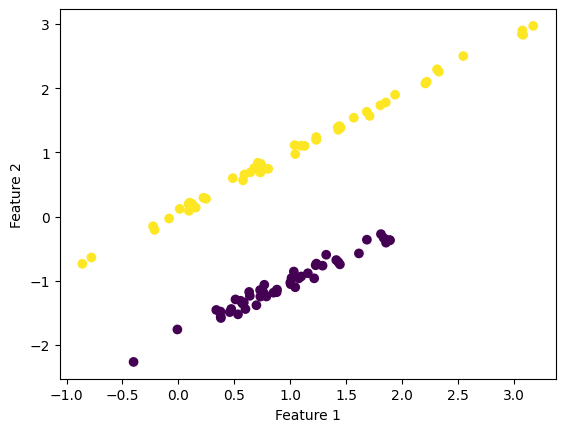

In [39]:
plt.scatter(X[:,0],X[:,1],c=y)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

In [40]:
def step(z):
  if  z >= 0:
    return 1
  else :
    return 0


In [41]:
def perceptron(X,y):
  X = np.insert(X,0,1,axis=1)
  weights = np.ones(X.shape[1])
  lr = 0.1

  for i in range(1000):
    j = np.random.randint(0,100)
    y_hat = step(np.dot(X[j],weights))
    weights = weights+lr*(y[j]-y_hat)*X[j]

  return weights[0],weights[1:]

In [42]:
intercept,coefficients = perceptron(X,y)

In [43]:
print("Intercept:", intercept)
print("Coefficients:", coefficients)

Intercept: 0.7000000000000001
Coefficients: [-0.48753361  1.22381791]


In [44]:
x1 = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)

In [45]:
x2 = -(intercept + coefficients[0] * x1) / coefficients[1]

In [46]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (100, 2)
y shape: (100,)


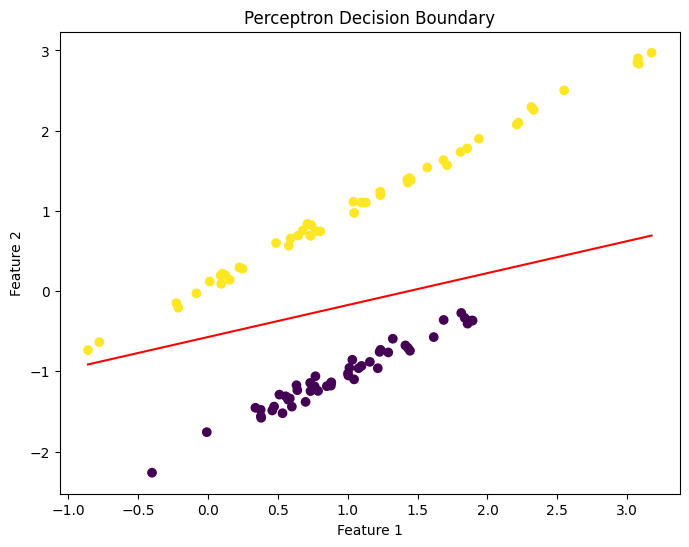

In [47]:
plt.figure(figsize=(8, 6))

plt.scatter(X[:, 0], X[:, 1], c=y)

plt.plot(x1, x2, color="red")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Perceptron Decision Boundary")

plt.show()

# Logistic Regression

Logistic Regression is a supervised machine learning algorithm used primarily for **classification problems**.

Although its name contains "Regression", it is a **classification algorithm**.

For binary classification, Logistic Regression predicts the probability that a data point belongs to class 1.

The basic idea is:

Input Features
        ↓
Linear Combination
        ↓
z = w₀ + w₁x₁ + w₂x₂
        ↓
Sigmoid Function
        ↓
Probability
        ↓
Class 0 or 1

In [48]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size = 0.2,random_state = 42,stratify = y
)

In [49]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (80, 2)
X_test: (20, 2)
y_train: (80,)
y_test: (20,)


In [50]:
from sklearn.preprocessing import  StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [51]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

In [52]:
model.fit(X_train_scaled,y_train)

LogisticRegression()

In [53]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: [0.07920295]
Coefficients: [[-1.43015704  3.44292264]]


In [54]:
y_pred = model.predict(X_test_scaled)
print(y_pred)

[1 1 1 1 0 0 0 1 0 0 0 1 0 0 0 1 1 0 1 1]


In [57]:
from sklearn.metrics  import accuracy_score
accuracy = accuracy_score(y_test,y_pred)
print("accuracy :",accuracy)

accuracy : 1.0


In [58]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[10  0]
 [ 0 10]]


In [59]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



In [60]:
x1 = np.linspace(
    X_train_scaled[:, 0].min(),
    X_train_scaled[:, 0].max(),
    100
)

x2 = -(
    model.intercept_[0] +
    model.coef_[0][0] * x1
) / model.coef_[0][1]

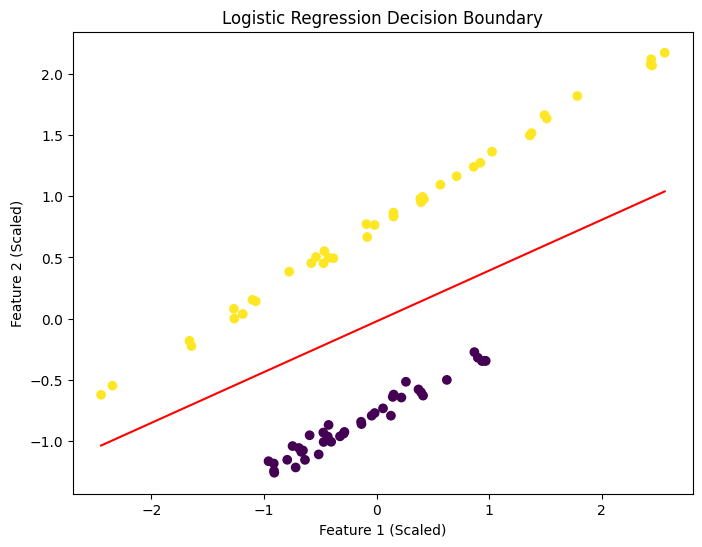

In [61]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_train_scaled[:, 0],
    X_train_scaled[:, 1],
    c=y_train
)

plt.plot(x1, x2, color="red")

plt.xlabel("Feature 1 (Scaled)")
plt.ylabel("Feature 2 (Scaled)")
plt.title("Logistic Regression Decision Boundary")

plt.show()